# Data Exploration: Twitter15 / Twitter16 Cascade Graphs
Loads both datasets, prints summary statistics, plots class distributions and graph sizes, and visualizes example cascades.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch

from data.dataset import CascadeDataset, LABEL_MAP

DATA_ROOT = "../Twitter15_16_dataset-main"
LABEL_NAMES = {v: k for k, v in LABEL_MAP.items()}
COLORS = {0: "#e74c3c", 1: "#2ecc71", 2: "#f39c12", 3: "#3498db"}

In [2]:
ds15 = CascadeDataset(root=DATA_ROOT, name="twitter15")
ds16 = CascadeDataset(root=DATA_ROOT, name="twitter16")
print(f"Twitter15: {len(ds15)} graphs")
print(f"Twitter16: {len(ds16)} graphs")

Twitter15: 1490 graphs
Twitter16: 818 graphs


In [23]:
ds15[0]

Data(x=[146, 29], edge_index=[2, 151], edge_attr=[151, 1], y=[1], num_nodes=146)

In [24]:
ds15[0].x

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 2.5000e-01, 2.5000e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [4.1768e-05, 5.0000e-01, 2.5000e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [9.9840e-01, 5.0000e-01, 2.5000e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [9.9915e-01, 5.0000e-01, 2.5000e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.0000e+00, 5.0000e-01, 2.5000e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]])

In [26]:
ds15[0].edge_index

tensor([[  0,   1,   1,   1,   1,   5,   5,   1,   1,   1,   1,   5,   1,   5,
           1,   1,   8,   1,   1,  18,   1,   1,  18,   1,   1,   1,   8,  16,
           1,   1,   1,   1,  26,   1,   1,   1,  16,   1,   1,   1,   1,  25,
           1,   1,   1,   1,   1,  16,   1,   1,   1,   1,   1,   1,   1,   1,
           1,  16,   1,   1,   1,   1,   8,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,  60,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   5,  75,  16,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   8,   8,   1,   1,   1,   1,   1,
         104,  16,   1,   8,   1,  78,  90,   8,   1,   1,   1,   1,   1,   1,
           1,  16, 104,   1,   5, 117,   5,   5,   1,   1,   1,   1, 102,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1],
        [  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
          15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  2

In [3]:
def dataset_stats(ds, name):
    ys = [ds[i].y.item() for i in range(len(ds))]
    ns = [ds[i].num_nodes for i in range(len(ds))]
    es = [ds[i].edge_index.shape[1] for i in range(len(ds))]
    ns_t = torch.tensor(ns, dtype=torch.float)
    es_t = torch.tensor(es, dtype=torch.float)
    class_dist = Counter(ys)

    print(f"\n{'='*40}")
    print(f" {name}")
    print(f"{'='*40}")
    print(f"  Total graphs : {len(ds)}")
    print(f"  Classes      : { {LABEL_NAMES[k]: v for k, v in sorted(class_dist.items())} }")
    print(f"  Nodes/graph  : min={int(ns_t.min())}  max={int(ns_t.max())}  mean={ns_t.mean():.1f}  median={ns_t.median():.1f}")
    print(f"  Edges/graph  : min={int(es_t.min())}  max={int(es_t.max())}  mean={es_t.mean():.1f}  median={es_t.median():.1f}")
    print(f"  Feature dim  : {ds[0].x.shape[1]}  (5 structural + 8 LapPE + 16 RWPE)")
    return ys, ns, es

ys15, ns15, es15 = dataset_stats(ds15, "Twitter15")
ys16, ns16, es16 = dataset_stats(ds16, "Twitter16")


 Twitter15
  Total graphs : 1490
  Classes      : {'false': 370, 'true': 372, 'unverified': 374, 'non-rumor': 374}
  Nodes/graph  : min=57  max=2991  mean=403.1  median=261.0
  Edges/graph  : min=56  max=3087  mean=419.1  median=272.0
  Feature dim  : 29  (5 structural + 8 LapPE + 16 RWPE)

 Twitter16
  Total graphs : 818
  Classes      : {'false': 205, 'true': 207, 'unverified': 201, 'non-rumor': 205}
  Nodes/graph  : min=75  max=3090  mean=426.2  median=272.0
  Edges/graph  : min=74  max=3145  mean=444.4  median=279.0
  Feature dim  : 29  (5 structural + 8 LapPE + 16 RWPE)


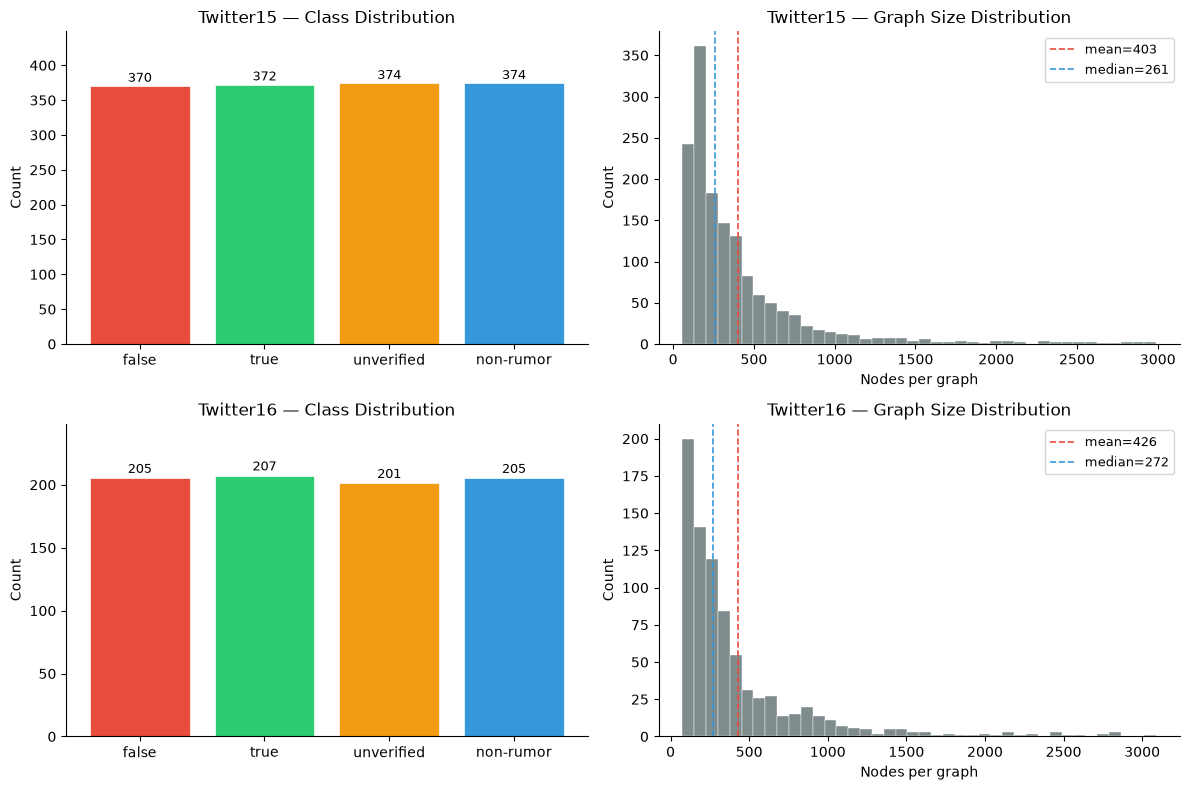

Saved data/distributions.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (ys, ns, name) in enumerate([
    (ys15, ns15, "Twitter15"),
    (ys16, ns16, "Twitter16"),
]):
    # Class distribution bar chart
    ax = axes[row, 0]
    counts = Counter(ys)
    labels = [LABEL_NAMES[i] for i in range(4)]
    vals   = [counts.get(i, 0) for i in range(4)]
    bars = ax.bar(labels, vals, color=[COLORS[i] for i in range(4)], edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(val),
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{name} — Class Distribution")
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(vals) * 1.2)
    ax.spines[["top", "right"]].set_visible(False)

    # Graph size histogram
    ax = axes[row, 1]
    ax.hist(ns, bins=40, color="#7f8c8d", edgecolor="white", linewidth=0.3)
    ax.axvline(np.mean(ns), color="#e74c3c", linestyle="--", linewidth=1.2, label=f"mean={np.mean(ns):.0f}")
    ax.axvline(np.median(ns), color="#3498db", linestyle="--", linewidth=1.2, label=f"median={np.median(ns):.0f}")
    ax.set_title(f"{name} — Graph Size Distribution")
    ax.set_xlabel("Nodes per graph")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../data/distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved data/distributions.png")

In [5]:
def pick_example(ds, label: int, max_nodes: int = 60):
    """Pick a readable cascade for a given label (small enough to visualise)."""
    for i in range(len(ds)):
        d = ds[i]
        if d.y.item() == label and d.num_nodes <= max_nodes:
            return d
    # fall back to first match regardless of size
    for i in range(len(ds)):
        if ds[i].y.item() == label:
            return ds[i]
    return None


def data_to_nx(data):
    G = nx.DiGraph()
    G.add_nodes_from(range(data.num_nodes))
    edges = data.edge_index.T.tolist()
    G.add_edges_from(edges)
    return G


def draw_cascade(ax, data, title):
    G = data_to_nx(data)
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
    except Exception:
        try:
            pos = nx.drawing.layout.planar_layout(G)
        except Exception:
            pos = nx.spring_layout(G, seed=42, k=1.5 / (data.num_nodes ** 0.5))

    # colour nodes by normalised depth (feature index 1)
    depths = data.x[:, 1].numpy()
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=20,
                           node_color=depths, cmap="YlOrRd", vmin=0, vmax=1)
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True,
                           arrowsize=6, width=0.4, alpha=0.5,
                           edge_color="#555555")
    # label only the root
    nx.draw_networkx_labels(G, pos, labels={0: "ROOT"}, ax=ax, font_size=6)
    ax.set_title(f"{title}\n{data.num_nodes} nodes, {data.edge_index.shape[1]} edges",
                 fontsize=9)
    ax.axis("off")

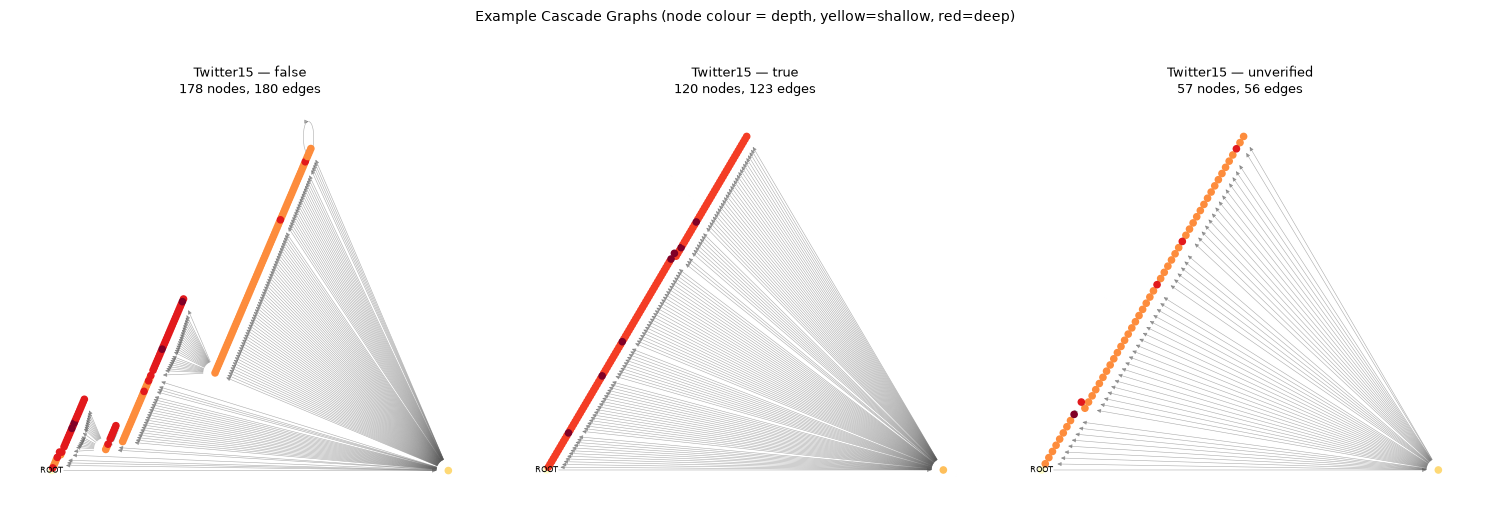

Saved data/example_cascades.png


In [6]:
# Visualise one example per class (3 classes shown; pick false/true/unverified for contrast)
target_labels = [0, 1, 2]  # false, true, unverified
examples = [pick_example(ds15, lbl) for lbl in target_labels]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, data, lbl in zip(axes, examples, target_labels):
    draw_cascade(ax, data, f"Twitter15 — {LABEL_NAMES[lbl]}")

plt.suptitle("Example Cascade Graphs (node colour = depth, yellow=shallow, red=deep)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig("../data/example_cascades.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved data/example_cascades.png")

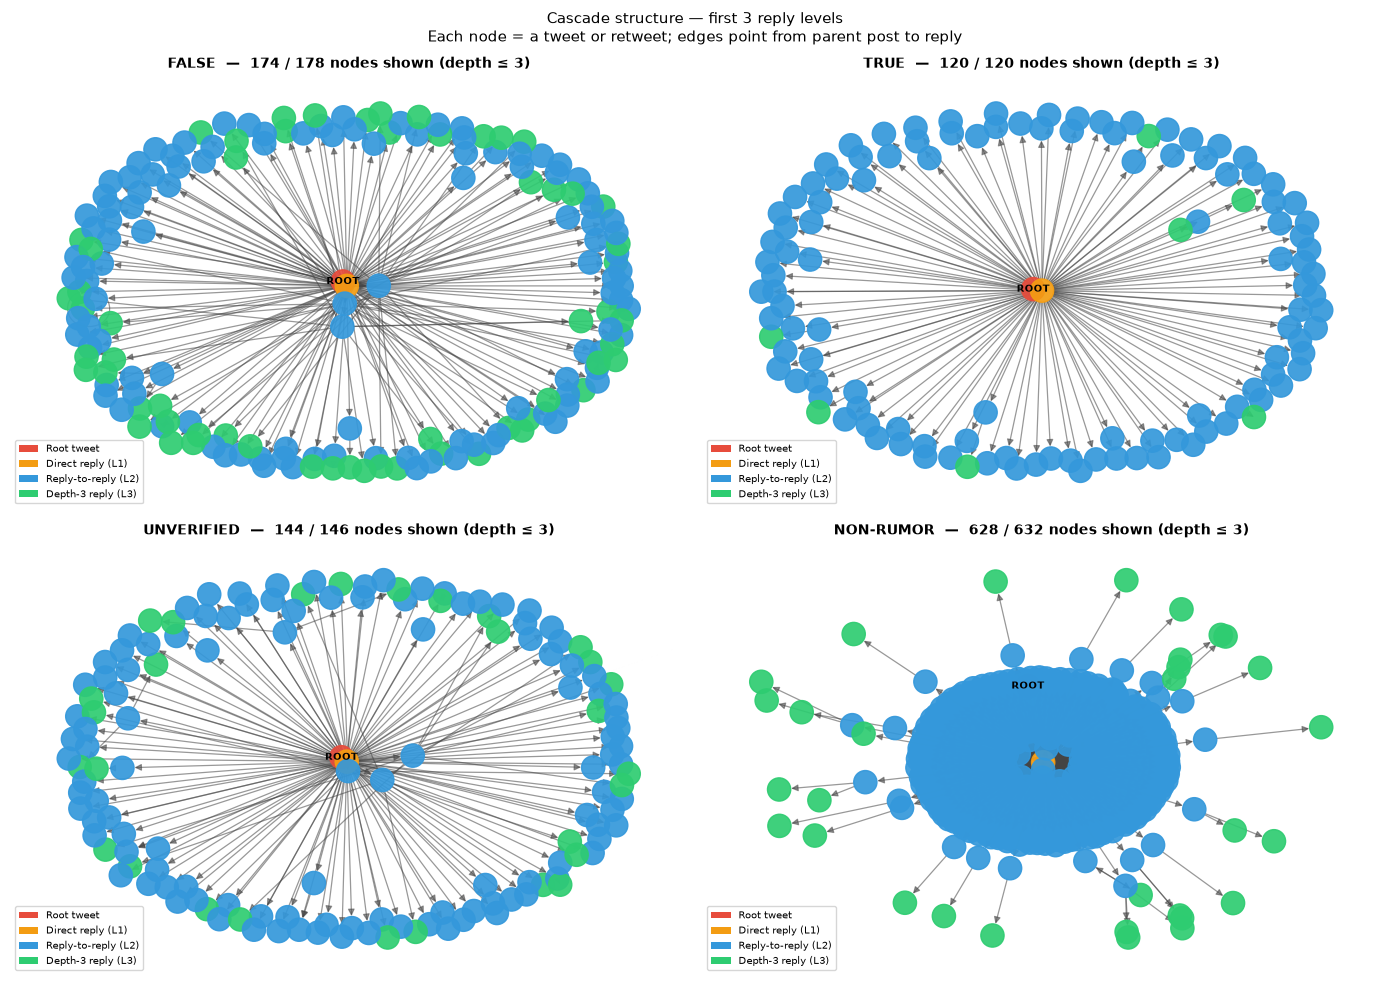

Saved data/illustrative_cascades.png


In [7]:

from collections import deque
from matplotlib.patches import Patch

DEPTH_COLORS = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]
DEPTH_LABELS = ["Root tweet", "Direct reply (L1)", "Reply-to-reply (L2)", "Depth-3 reply (L3)"]


def subgraph_by_depth(data, max_depth=3):
    """BFS from root (node 0); returns kept nodes, filtered edges, depth mapping."""
    adj = {}
    for u, v in data.edge_index.T.tolist():
        adj.setdefault(int(u), []).append(int(v))

    depth_of = {0: 0}
    queue = deque([0])
    while queue:
        node = queue.popleft()
        if depth_of[node] >= max_depth:
            continue
        for nb in adj.get(node, []):
            if nb not in depth_of:
                depth_of[nb] = depth_of[node] + 1
                queue.append(nb)

    kept = set(depth_of)
    edges = [(int(u), int(v)) for u, v in data.edge_index.T.tolist()
             if int(u) in kept and int(v) in kept]
    return kept, edges, depth_of


def first_example(ds, label):
    for i in range(len(ds)):
        if ds[i].y.item() == label:
            return ds[i]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, lbl in zip(axes.flat, range(4)):
    data = first_example(ds15, lbl)
    kept, edges, depth_of = subgraph_by_depth(data, max_depth=3)

    G = nx.DiGraph()
    G.add_nodes_from(kept)
    G.add_edges_from(edges)

    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
    except Exception:
        pos = nx.spring_layout(G, seed=42)

    node_colors = [DEPTH_COLORS[depth_of[n]] for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=280, node_color=node_colors, alpha=0.92)
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=10,
                           width=0.9, alpha=0.55, edge_color="#444444")
    nx.draw_networkx_labels(G, pos, labels={0: "ROOT"}, ax=ax, font_size=7, font_weight="bold")

    max_d = max(depth_of.values())
    legend = [Patch(fc=DEPTH_COLORS[d], label=DEPTH_LABELS[d]) for d in range(max_d + 1)]
    ax.legend(handles=legend, fontsize=7, loc="lower left", framealpha=0.8)

    ax.set_title(
        f"{LABEL_NAMES[lbl].upper()}  —  {len(kept)} / {data.num_nodes} nodes shown (depth ≤ 3)",
        fontsize=10, fontweight="bold",
    )
    ax.axis("off")

plt.suptitle(
    "Cascade structure — first 3 reply levels\n"
    "Each node = a tweet or retweet; edges point from parent post to reply",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("../data/illustrative_cascades.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved data/illustrative_cascades.png")


In [8]:
# Feature sanity check
d = ds15[0]
feat_names = ["timestamp", "depth", "in_degree", "subtree_size", "branching",
              *[f"lapPE_{i}" for i in range(8)],
              *[f"rwPE_{i}" for i in range(16)]]
print("Feature stats (first graph in Twitter15):")
print(f"{'feature':<14} {'min':>8} {'max':>8} {'mean':>8}")
print("-" * 42)
for i, name in enumerate(feat_names):
    col = d.x[:, i]
    print(f"{name:<14} {col.min().item():>8.3f} {col.max().item():>8.3f} {col.mean().item():>8.3f}")

Feature stats (first graph in Twitter15):
feature             min      max     mean
------------------------------------------
timestamp         0.000    1.000    0.086
depth             0.000    1.000    0.551
in_degree         0.000    1.000    0.259
subtree_size      0.000    1.000    0.015
branching         0.000    1.000    0.009
lapPE_0          -0.000    0.009    0.000
lapPE_1          -0.104    0.989    0.007
lapPE_2          -1.000    0.010   -0.006
lapPE_3          -0.034    0.997    0.006
lapPE_4          -0.186    0.955    0.008
lapPE_5          -0.996    0.043   -0.005
lapPE_6          -0.981    0.074   -0.006
lapPE_7          -0.540    0.685    0.006
rwPE_0            0.000    0.000    0.000
rwPE_1            0.000    1.000    0.014
rwPE_2            0.000    0.000    0.000
rwPE_3            0.000    1.000    0.014
rwPE_4            0.000    0.000    0.000
rwPE_5            0.000    1.000    0.014
rwPE_6            0.000    0.000    0.000
rwPE_7            0.000    1.000 